In [1]:
import train
%load_ext autoreload
%autoreload 2

/home/fbraidi/miniconda3/envs/thesis-env/lib/python3.7/site-packages/tensorflow/python/framework/dtypes.py:526: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint8 = np.dtype([("qint8", np.int8, 1)])
/home/fbraidi/miniconda3/envs/thesis-env/lib/python3.7/site-packages/tensorflow/python/framework/dtypes.py:527: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_quint8 = np.dtype([("quint8", np.uint8, 1)])
/home/fbraidi/miniconda3/envs/thesis-env/lib/python3.7/site-packages/tensorflow/python/framework/dtypes.py:528: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint16 = np.dtype([("qint16", np.int16, 1)])
/home/fbraidi/miniconda3/env

In [2]:
import tools
from analysis import performance
from analysis import standard_analysis
from analysis import clustering
from analysis import variance
from analysis import taskset
from analysis import varyhp
from analysis import data_analysis
from analysis import contextdm_analysis
from analysis import posttrain_analysis
from network import Model
import tensorflow as tf

In [19]:
train.train(model_dir='prova2', 
            hp={'learning_rate': 0.001, 
                'n_rnn': 1024,#512, 16384,8192,1024
                'w_rec_init': 'randgauss',#'randortho'
                'b_rec_init': 'uniform',
                'rule_strength': 1.,
                'no_rule': False,
                'target_perf':1.0,
                'activation': 'softplus',
                'alpha':0.2,
                'use_separate_input':True},
            ruleset='all',
            rule_trains = ['fdgo','fdanti','delaygo','delayanti'])#

batch_size_train     = 64
batch_size_test      = 512
in_type              = normal
rnn_type             = LeakyRNN
use_separate_input   = True
loss_type            = lsq
optimizer            = adam
activation           = softplus
tau                  = 100
dt                   = 20
alpha                = 0.2
sigma_rec            = 0.05
sigma_x              = 0.01
w_rec_init           = randgauss
w_in_init            = randgauss
w_out_init           = glorot_uniform
b_rec_init           = uniform
b_out_init           = zeros
l1_h                 = 0
l2_h                 = 0
l1_weight            = 0
l2_weight            = 0
l2_weight_init       = 0
p_weight_train       = None
target_perf          = 1.0
n_eachring           = 32
num_ring             = 2
n_rule               = 22
rule_start           = 65
n_input              = 87
n_output             = 33
n_rnn                = 1024
ruleset              = all
save_name            = test
learning_rate        = 0.001
c_intsyn             = 

/home/fbraidi/Thesis/Danny/multitask/network.py:40: RuntimeWarning: invalid value encountered in true_divide
  temp_cos = np.sum(y*np.cos(pref), axis=-1)/temp_sum
/home/fbraidi/Thesis/Danny/multitask/network.py:41: RuntimeWarning: invalid value encountered in true_divide
  temp_sin = np.sum(y*np.sin(pref), axis=-1)/temp_sum
/home/fbraidi/Thesis/Danny/multitask/network.py:43: RuntimeWarning: invalid value encountered in remainder
  return np.mod(loc, 2*np.pi)


fdgo           | cost 0.503810| c_reg 0.000000  | perf 0.00
fdanti         | cost 0.471689| c_reg 0.000000  | perf 0.00
delaygo        | cost 0.588976| c_reg 0.000000  | perf 0.00
delayanti      | cost 0.577606| c_reg 0.000000  | perf 0.00
Model saved in file: prova2/model.ckpt
Trial   64000  | Time 361.69 s  | Now training fdgo & fdanti & delaygo & delayanti
fdgo           | cost 0.481350| c_reg 0.000000  | perf 0.00
fdanti         | cost 0.482252| c_reg 0.000000  | perf 0.00
delaygo        | cost 0.541973| c_reg 0.000000  | perf 0.00
delayanti      | cost 0.562485| c_reg 0.000000  | perf 0.00
Model saved in file: prova2/model.ckpt
Trial   96000  | Time 538.96 s  | Now training fdgo & fdanti & delaygo & delayanti
fdgo           | cost 0.480895| c_reg 0.000000  | perf 0.00
fdanti         | cost 0.458044| c_reg 0.000000  | perf 0.00
delaygo        | cost 0.573447| c_reg 0.000000  | perf 0.00
delayanti      | cost 0.617812| c_reg 0.000000  | perf 0.00
Model saved in file: prova2/model.ck

Overwrite original dt with 1.0


INFO:tensorflow:Restoring parameters from fdgo_fdanti_delaygo/model.ckpt
Model restored from file: fdgo_fdanti_delaygo/model.ckpt


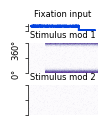

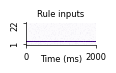

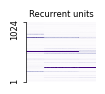

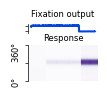

In [6]:
standard_analysis.schematic_plot(model_dir='fdgo_fdanti_delaygo', rule='fdanti')

Overwrite original dt with 1.0


INFO:tensorflow:Restoring parameters from fdgo_fdanti_delaygo/model.ckpt
Model restored from file: fdgo_fdanti_delaygo/model.ckpt


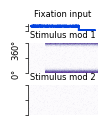

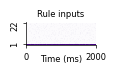

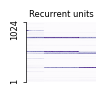

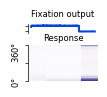

In [7]:
standard_analysis.schematic_plot(model_dir='fdgo_fdanti_delaygo',rule='fdgo')

Overwrite original dt with 1.0
INFO:tensorflow:Restoring parameters from fdgo_fdanti_delaygo/model.ckpt
Model restored from file: fdgo_fdanti_delaygo/model.ckpt


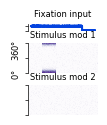

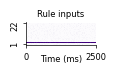

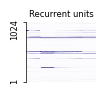

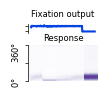

In [8]:
standard_analysis.schematic_plot(model_dir='fdgo_fdanti_delaygo', rule='delaygo')

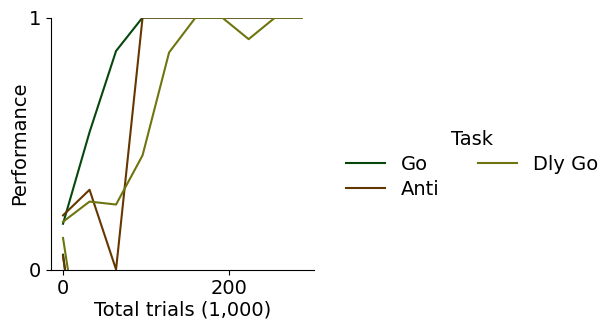

In [9]:
performance.plot_performanceprogress(model_dir='fdgo_fdanti_delaygo')

In [11]:
train.train(model_dir='compositional_delayanti', 
                hp={'learning_rate': 0.01, 
                    'n_rnn': 256,
                    'w_rec_init': 'randgauss',
                    'b_rec_init': 'uniform',
                    'rule_strength': 0.,
                    'no_rule': False,
                    'target_perf': 0.90,
                    'activation': 'softplus',
                    'alpha': 0.2,
                    'use_separate_input':True,
                    'train_rule_bias':True},
                ruleset='all',
                rule_trains=['delayanti'], # Current rule to train
                pretrained_dir='fdgo_fdanti_delaygo',
                apply_pretrained_params='all',
                trainables='rule_bias')

INFO:tensorflow:Restoring parameters from fdgo_fdanti_delaygo/model.ckpt
Model restored from file: fdgo_fdanti_delaygo/model.ckpt


batch_size_train     = 64
batch_size_test      = 512
in_type              = normal
rnn_type             = LeakyRNN
use_separate_input   = True
loss_type            = lsq
optimizer            = adam
activation           = softplus
tau                  = 100
dt                   = 20
alpha                = 0.2
sigma_rec            = 0.05
sigma_x              = 0.01
w_rec_init           = randgauss
w_in_init            = randgauss
w_out_init           = glorot_uniform
b_rec_init           = uniform
b_out_init           = zeros
l1_h                 = 0
l2_h                 = 0
l1_weight            = 0
l2_weight            = 0
l2_weight_init       = 0
p_weight_train       = None
target_perf          = 0.9
n_eachring           = 32
num_ring             = 2
n_rule               = 22
rule_start           = 65
n_input              = 87
n_output             = 33
n_rnn                = 256
ruleset              = all
save_name            = test
learning_rate        = 0.01
c_intsyn             = 0


Overwrite original dt with 1.0
INFO:tensorflow:Restoring parameters from fdgo_fdanti_delaygo2/model.ckpt
Model restored from file: fdgo_fdanti_delaygo2/model.ckpt


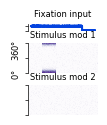

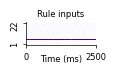

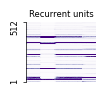

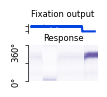

In [ ]:
standard_analysis.schematic_plot(model_dir='compositional_delayanti', rule='delayanti')